In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PMT:
  def __init__(self, dt, bcs, V_0 = 0):
    self.t = np.arange(0, 25 * bcs, dt)
    self.V = np.zeros_like(self.t, dtype=float) + V_0

  def pulse(self, t_0, q=1, sigma=3.0, tau=5.0, R_tilde=1.0):
    t_tilde = (sigma ** 2) / tau
    C = np.exp(-0.5 * (sigma / tau) ** 2)

    t_shifted = self.t - t_0

    gauss_mask = t_shifted <= t_tilde
    self.V[gauss_mask] += q * R_tilde * np.exp(-0.5 * (t_shifted[gauss_mask] / sigma) ** 2)

    exp_mask = t_shifted > t_tilde
    self.V[exp_mask] += (q * R_tilde / C) * np.exp(-t_shifted[exp_mask] / tau)

    return self

  def noise(self, noise_mean, noise_std):
    rng = np.random.default_rng()
    white_noise = rng.normal(loc=noise_mean, scale=noise_std, size=self.V.shape)
    self.V += white_noise
    return self

  def digitize(self, num_bits=12):
        max_int = (1 << num_bits) - 1
        v_scaled = np.round(self.V * max_int)
        v_clipped = np.clip(v_scaled, 0, max_int)
        if num_bits <= 8:
            dtype = np.uint8
        elif num_bits <= 16:
            dtype = np.uint16
        elif num_bits <= 32:
            dtype = np.uint32
        self.V = v_clipped.astype(dtype)
        return self

  def get(self):
    return self.t, self.V


In [3]:
from collections import deque

class CFD:
  def __init__(self, dt, delay_samples, scale_shift, t_cfd):
    self.delay_fifo = deque([0.0]*delay_samples, maxlen=delay_samples)
    self.scale_shift = scale_shift

  def clk(self, input): # function executed for each clock cycle
    out_p = int(self.delay_fifo.popleft())
    out_n = -int((input >> self.scale_shift))
    #out_n = -int((input / self.scale_shift))
    self.delay_fifo.append(input)

    return { "p": out_p, "n": out_n, "sum": out_p + out_n }

In [4]:
class ZeroCrossingDetector:
  def __init__(self, thr):
    self.thr = thr # threshold
    self.state_pos = 0 # 0 - negative, 1 - positive
    self.zc_pulse = 0

  def clk(self, input): # function executed for each clock cycle
    if input > self.thr and self.state_pos == 0:
      self.state_pos = 1
      self.zc_pulse = 1
    elif input < -self.thr and self.state_pos == 1:
      self.state_pos = 0
      self.zc_pulse = 1
    else:
      self.zc_pulse = 0

    return self.zc_pulse and self.state_pos

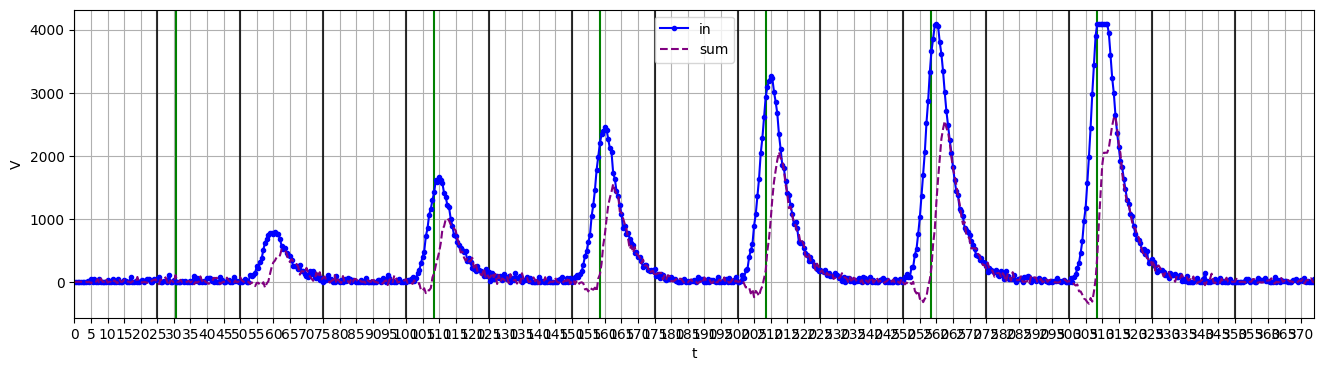

In [27]:
# 2 GHz, 5 BCs
DT = 0.5
BCs = 15
t, V = PMT(DT, BCs) \
  .pulse(60, q=0.2) \
  .pulse(110, q=0.4) \
  .pulse(160, q=0.6) \
  .pulse(210, q=0.8) \
  .pulse(260, q=1.0) \
  .pulse(310, q=1.2) \
  .noise(0, 0.01) \
  .digitize() \
  .get()

cfd = CFD(DT, delay_samples=4, scale_shift=1, t_cfd=15)
zcd = ZeroCrossingDetector(thr=100)
data = []
for sample in V:
  cfd_data = cfd.clk(sample)
  cfd_data['pulse'] = zcd.clk(cfd_data["sum"])
  data.append(cfd_data)

p_vals = [item['p'] for item in data]
n_vals = [item['n'] for item in data]
sum_vals = [item['sum'] for item in data]
pulse_vals = [item['pulse'] for item in data]

plt.figure(figsize=(16, 4))

for time, pulse_detected in zip(t, pulse_vals):
    if pulse_detected == 1:
        plt.axvline(x=time, color='green')

x_max = int(np.max(t))
plt.xlim((0, x_max))
for x in range(0, x_max, 25):
    plt.axvline(x=x, color='k', linewidth=1.5, alpha=0.8)
plt.xticks(np.arange(0, x_max, 5))

plt.plot(t, V, label='in', color='blue', marker='.')
# plt.plot(t, n_vals, label='n', color='red', linestyle='--')
plt.plot(t, sum_vals, label='sum', color='purple', linestyle='--')

plt.xlabel('t')
plt.ylabel('V')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
for v in V:
  print(v)

0
0
74
0
9
0
25
0
12
0
0
0
0
33
46
0
0
0
0
36
0
0
0
0
0
7
0
61
0
0
0
0
55
50
0
46
44
27
0
0
0
0
78
22
0
38
0
68
2
0
0
0
38
0
0
24
0
0
0
26
6
0
28
75
0
8
0
76
0
32
76
21
65
0
0
0
0
55
0
0
10
0
0
6
0
3
0
4
32
0
0
0
78
28
0
0
0
22
0
0
33
12
52
0
70
23
112
77
112
137
243
217
392
464
532
545
727
790
863
793
791
836
845
699
648
560
598
510
446
433
289
340
211
277
214
239
170
239
153
181
174
46
61
20
66
122
83
112
101
1
72
41
43
0
20
63
3
61
0
0
74
24
0
0
0
52
11
0
6
20
39
3
34
40
48
52
0
0
14
32
37
48
7
75
0
0
0
2
0
39
0
0
0
0
0
4
0
0
0
0
36
0
0
77
98
39
18
179
288
370
312
545
685
858
996
1095
1291
1489
1538
1568
1670
1665
1558
1395
1309
1221
966
1060
917
788
676
685
589
555
507
445
359
317
290
263
290
297
164
189
241
158
134
122
128
104
104
116
122
33
64
11
96
101
51
79
50
100
0
61
39
52
5
0
0
53
18
6
45
0
0
0
5
6
116
73
16
7
0
17
23
0
0
44
0
0
0
0
16
0
0
27
0
0
43
0
0
23
67
42
50
71
142
215
349
442
577
734
992
1314
1459
1756
1995
2243
2212
2411
2397
2412
2301
2138
1938
1888
1614
1444
1338


In [ ]:
# Print zero-crossover detection times (to verify if constant fraction is actually constant)
for time, pulse_detected in zip(t, pulse_vals):
    if pulse_detected == 1:
      print(time)

59.0
108.5
158.5
208.5
258.5
308.5
